Spearman correlation between odd and even peak times: ρ = -0.088, p = 0.149


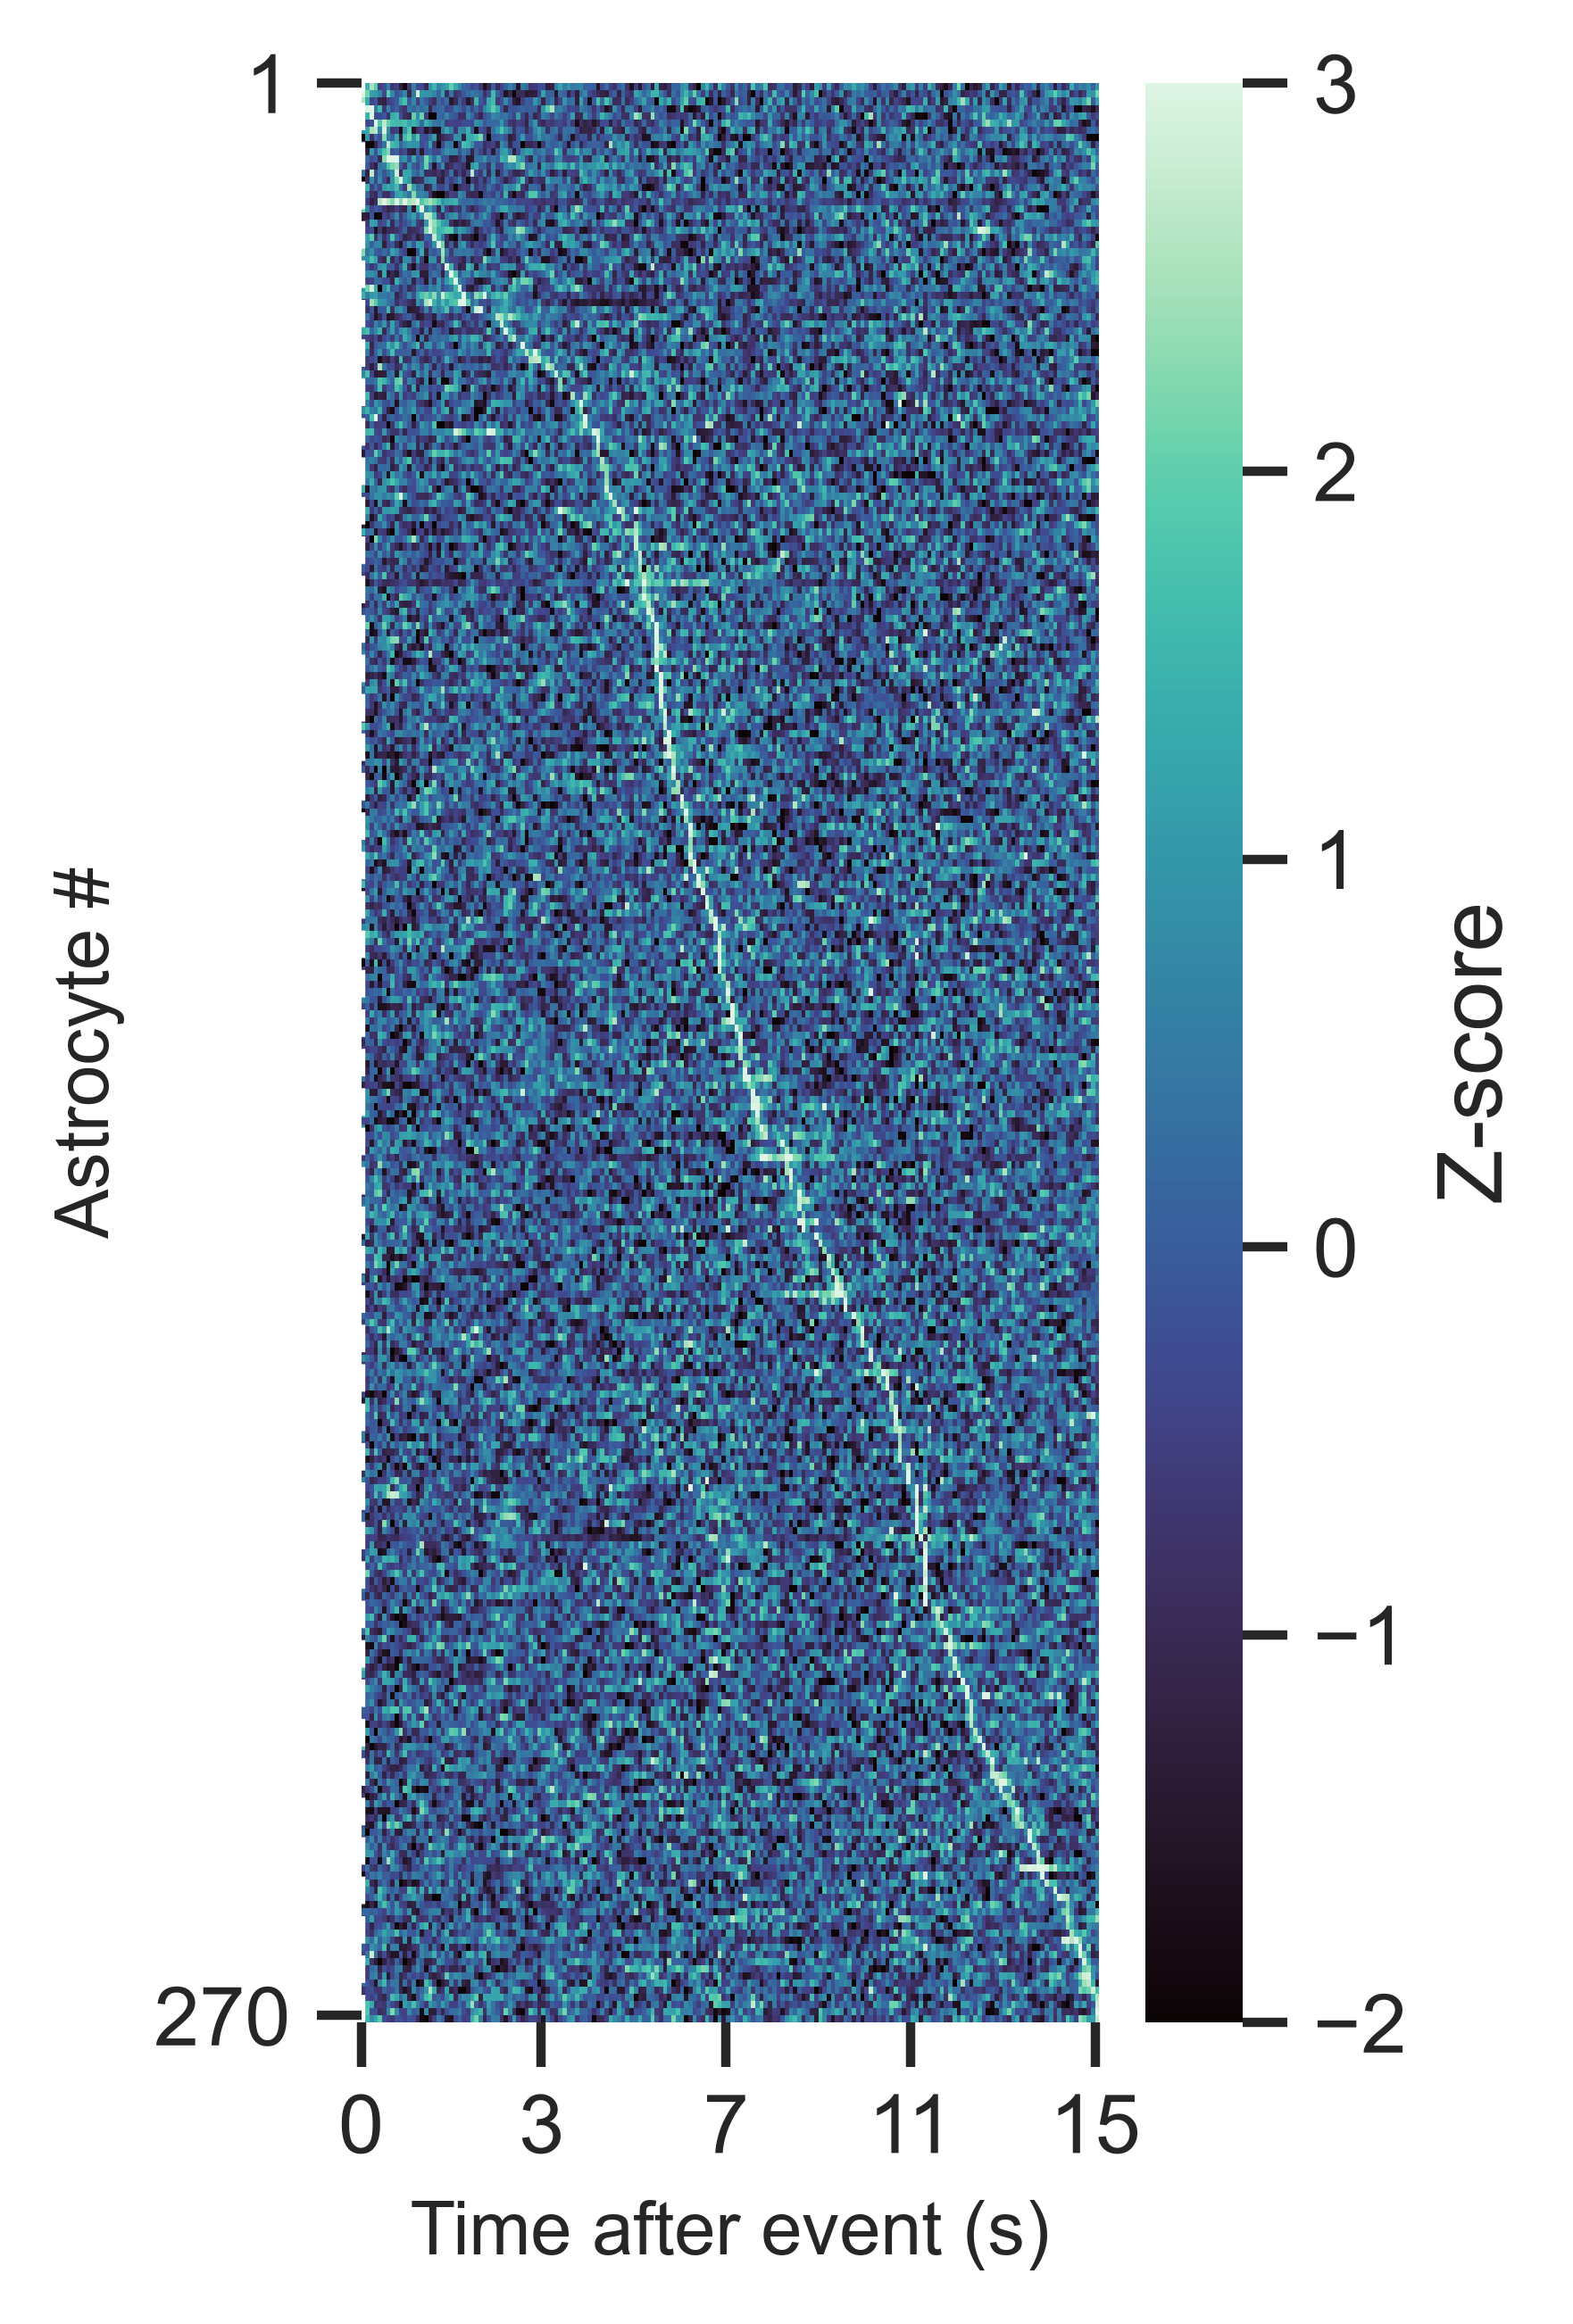

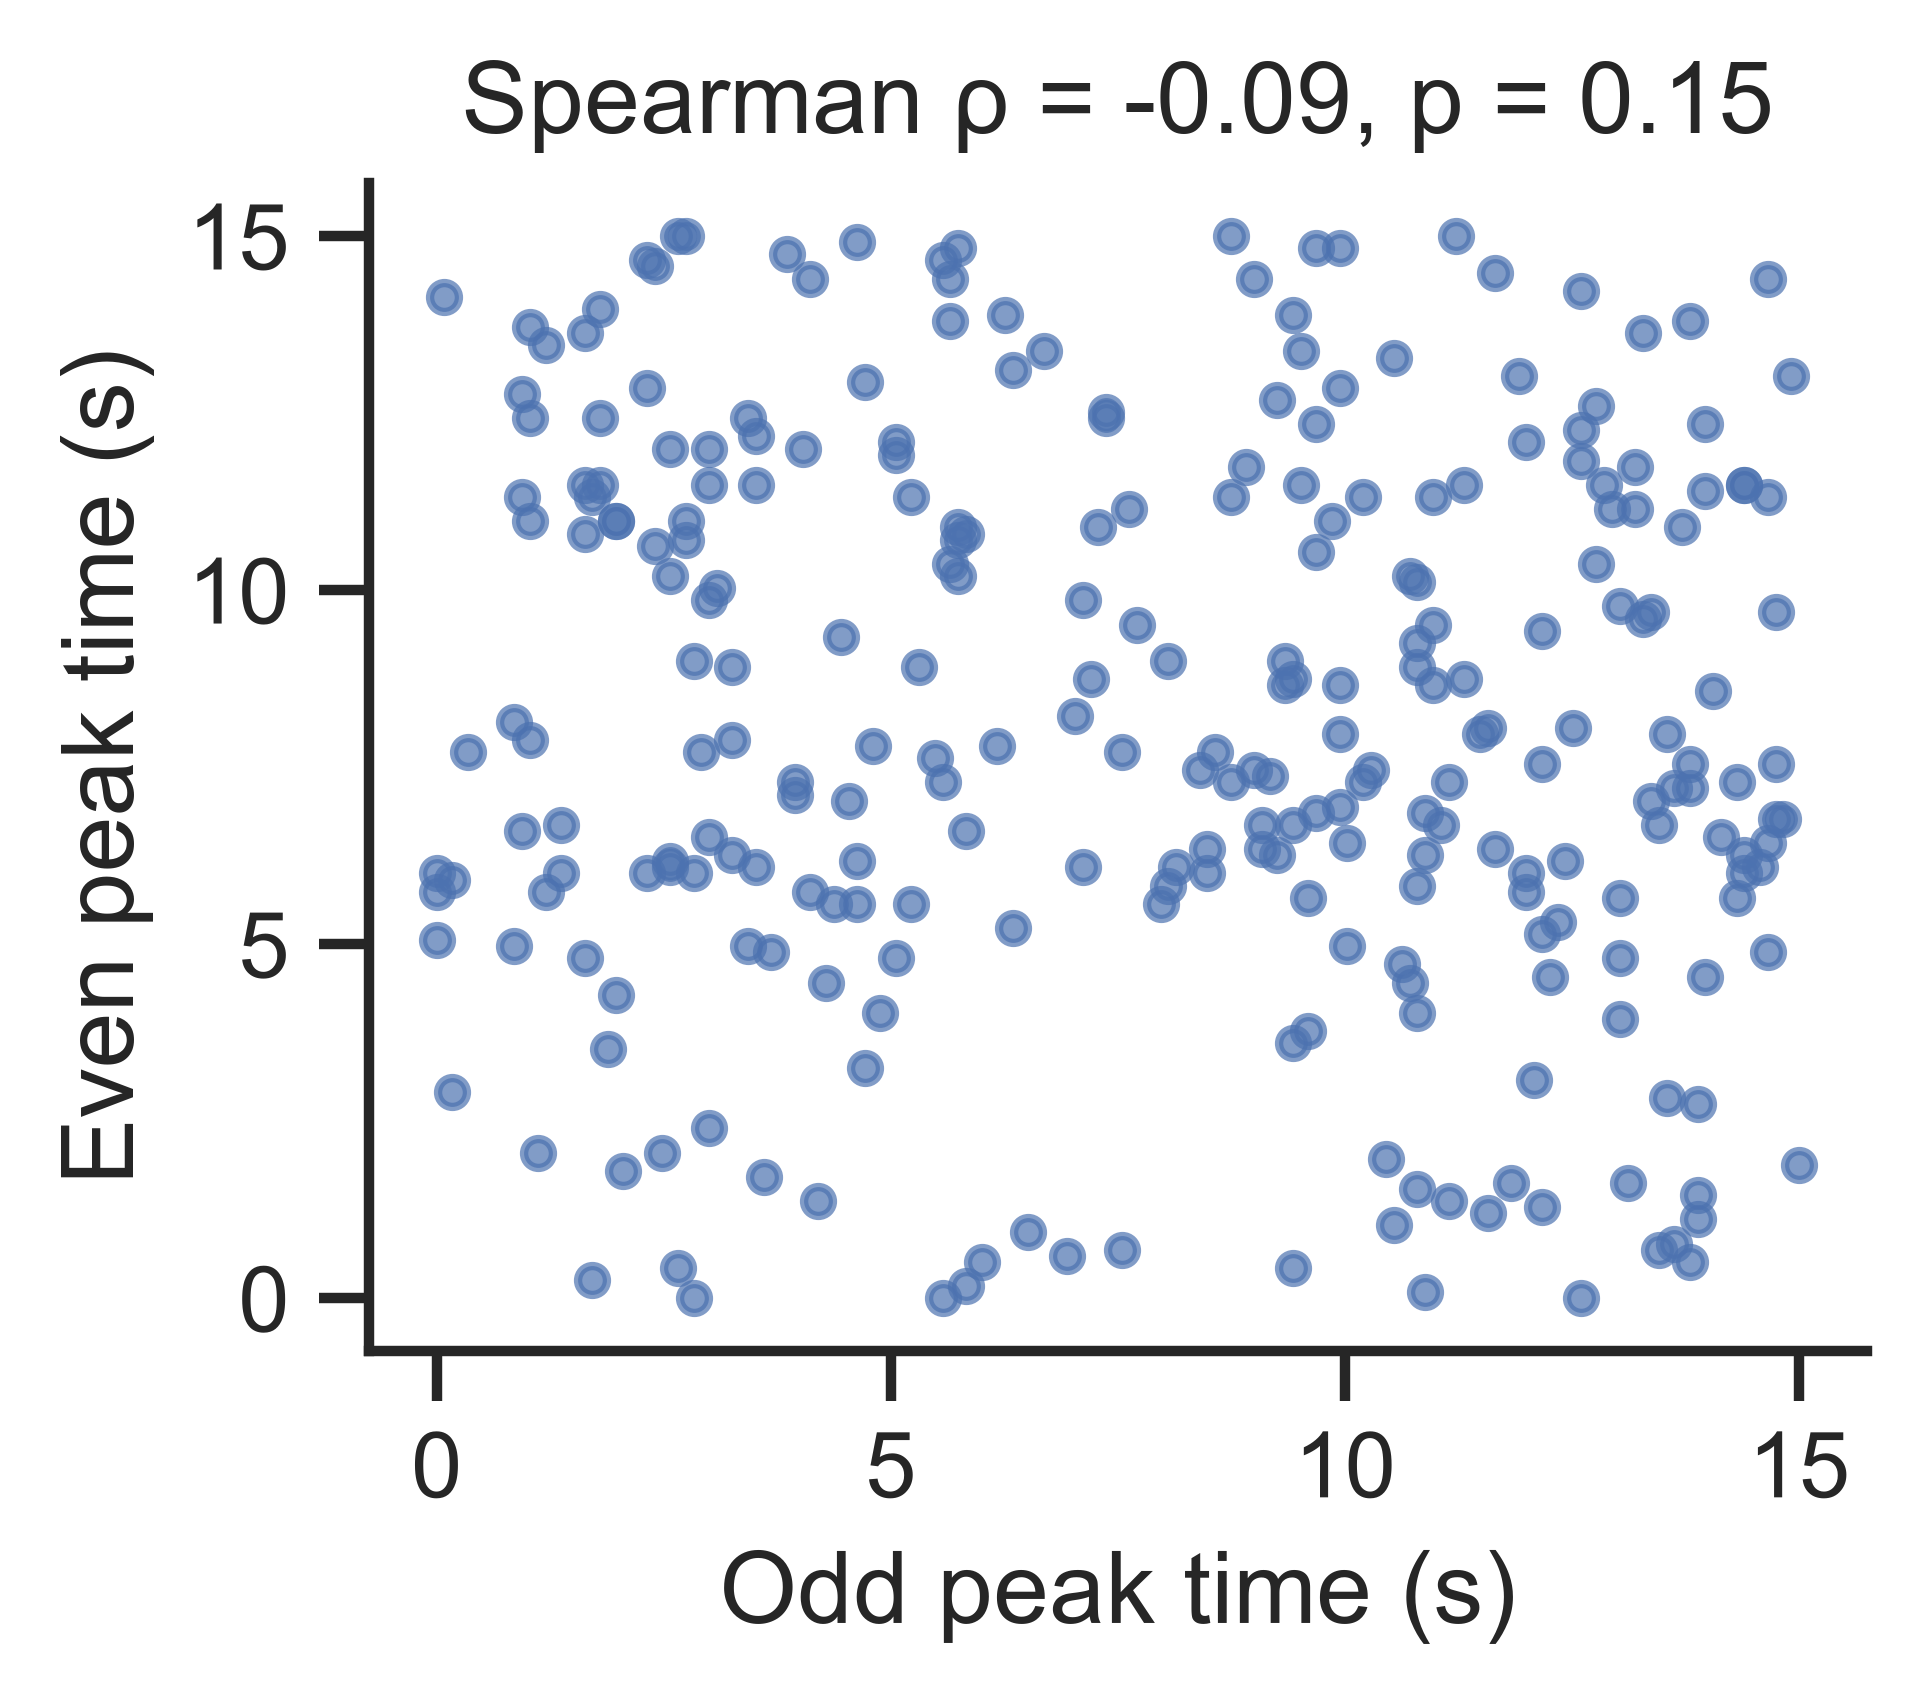

In [ ]:
from scipy.stats import spearmanr

# --- Align odd and even matrices to the same cells (same ones plotted) ---
# Use data from the most recent run_post_event_heatmap calls
# z_odd, idx_odd, order_odd already came from the first call
# Let's recompute z_even to ensure we use the same overlaps:

fig_even, ax_even, _, z_even, idx_even, _, t_rel = run_post_event_heatmap(
    traces=dFF, timestamps=time, events=even_times,
    window=15, vmin=-2, vmax=3,
    return_data=True
)

# Find cells common to both conditions
common_idx, pos_odd, pos_even = np.intersect1d(idx_odd, idx_even, return_indices=True)
z_odd_common = z_odd[pos_odd, :]
z_even_common = z_even[pos_even, :]

# --- Compute argmax times (indices of peak) ---
odd_peaks_idx = np.argmax(z_odd_common, axis=1)
even_peaks_idx = np.argmax(z_even_common, axis=1)

# Convert to seconds for interpretability
odd_peaks_time = t_rel[odd_peaks_idx]
even_peaks_time = t_rel[even_peaks_idx]

# --- Spearman’s rank correlation ---
rho, pval = spearmanr(odd_peaks_time, even_peaks_time)
print(f"Spearman correlation between odd and even peak times: ρ = {rho:.3f}, p = {pval:.3g}")

# Optional quick scatter plot
plt.figure(figsize=(3.5,3), dpi=600)
plt.scatter(odd_peaks_time, even_peaks_time, s=12, alpha=0.7)
plt.xlabel("Odd peak time (s)")
plt.ylabel("Even peak time (s)")
plt.title(f"Spearman ρ = {rho:.2f}, p = {pval:.2g}")
sns.despine()
plt.tight_layout()
#plt.savefig("/Users/suthardr/Desktop/siria_2p_poster_figs/crossvalled/astros_shock_crossvalled_corr.png")
plt.show()


In [ ]:
def run_cross_validated_analysis_v2(
    animal_id,
    traces,
    timestamps,
    odd_times,
    even_times,
    save_path_prefix,
    window=15.0,
    vmin=-2, vmax=3,
    do_shuffle=True,
    n_shuffles=10000,
    seed=None,
    two_sided=True
):
    """
    Reproduces the original behavior using run_post_event_heatmap:
      - Heatmaps: ODD sorted by ODD (left) ; ODD reordered by EVEN order (right)
      - Spearman: argmax(ODD_sorted_by_ODD) vs argmax(ODD_reordered_by_EVEN)
      - Optional shuffle null, RLM fit, and saved figures.
    Returns a dict with the same fields as your original function.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats
    try:
        import statsmodels.api as sm
    except Exception:
        sm = None  # handle gracefully if statsmodels isn't available

    # ---------- Helpers (same logic as original) ----------
    def shuffle_control_test(x, y, n_shuffles=1000, seed=None, two_sided=True):
        x = np.asarray(x); y = np.asarray(y)
        if x.shape[0] != y.shape[0]:
            raise ValueError(f"Length mismatch: x={x.shape[0]}, y={y.shape[0]}")
        if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
            raise ValueError("Non-finite values in x or y")
        rng = np.random.default_rng(seed)
        r_obs, p_obs = stats.spearmanr(x, y)
        sh = np.empty(n_shuffles, dtype=float)
        for i in range(n_shuffles):
            y_perm = rng.permutation(y)
            sh[i], _ = stats.spearmanr(x, y_perm)
        if two_sided:
            p_emp = (np.sum(np.abs(sh) >= abs(r_obs)) + 1) / (n_shuffles + 1)
        else:
            p_emp = (np.sum(sh >= r_obs) + 1) / (n_shuffles + 1) if r_obs >= 0 else (np.sum(sh <= r_obs) + 1) / (n_shuffles + 1)
        return {
            "r_obs": float(r_obs),
            "p_obs_parametric": float(p_obs),
            "shuffle_rhos": sh,
            "p_empirical": float(p_emp),
            "null_mean": float(np.mean(sh)),
            "null_std": float(np.std(sh, ddof=1)),
            "z_obs_vs_null": float((r_obs - np.mean(sh)) / (np.std(sh, ddof=1) + 1e-12)),
        }

    def plot_shuffle_null(shuffle_rhos, r_obs, figsize=(3.5, 3.5), dpi=600):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        ax.hist(shuffle_rhos, bins=30, density=True)
        ax.axvline(r_obs, linestyle='--')
        ax.set_xlabel('Spearman ρ')
        ax.set_ylabel('Density')
        ax.set_title('Shuffle null (permute Y across cells)')
        return fig, ax

    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})
    sns.set(style="ticks", font="Arial")

    # ---------- 1) Build ODD and EVEN z-matrices ----------
    # ODD: we’ll need z, idx_odd and the order by odd
    fig_tmp, ax_tmp, _, z_odd, idx_odd, order_odd, t_rel = run_post_event_heatmap(
        traces=traces, timestamps=timestamps, events=odd_times,
        window=window, vmin=vmin, vmax=vmax,
        return_data=True, title=None, ax=None
    )
    plt.close(fig_tmp)

    # EVEN: we only need its order; we’ll compute it then apply to ODD
    fig_tmp, ax_tmp, _, z_even, idx_even, order_even, _ = run_post_event_heatmap(
        traces=traces, timestamps=timestamps, events=even_times,
        window=window, vmin=vmin, vmax=vmax,
        return_data=True, title=None, ax=None
    )
    plt.close(fig_tmp)

    # Align cells between odd and even (original arrays were same N; here we guard)
    common_idx, pos_odd, pos_even = np.intersect1d(idx_odd, idx_even, return_indices=True)
    if common_idx.size == 0:
        raise ValueError("No overlapping valid cells between ODD and EVEN splits.")

    z_odd_common  = z_odd[pos_odd, :]
    z_even_common = z_even[pos_even, :]

    # Map EVEN order (which is defined on idx_even) onto the common cells,
    # then use that to reorder ODD (this mirrors: odd_sorted_even = odd[idxs_24])
    # Reconstruct even order in terms of original cell ids:
    ref_order_cells_even = idx_even[order_even]
    # Keep only those cells that are in the common set, preserving even order:
    common_set = set(common_idx.tolist())
    even_order_on_common_cells = [c for c in ref_order_cells_even if c in common_set]

    # Build mapping from original cell id -> row in z_odd_common
    cur_map_odd = {cell: i for cell, i in zip(common_idx, range(common_idx.size))}
    mapped_even_order_rows_for_odd = np.array([cur_map_odd[c] for c in even_order_on_common_cells], dtype=int)

    # Left panel: ODD sorted by ODD
    odd_order_on_common = np.argsort(np.argmax(z_odd_common, axis=1))
    odd_sorted_by_odd = z_odd_common[odd_order_on_common, :]

    # Right panel: ODD reordered by EVEN order
    odd_reordered_by_even = z_odd_common[mapped_even_order_rows_for_odd, :]

    # ---------- 2) Heatmaps (shared Y + shared colorbar) ----------
    fig, axes = plt.subplots(1, 2, sharey=True, figsize=(7, 5), dpi=600)

    # Left
    hm1 = sns.heatmap(
        odd_sorted_by_odd, ax=axes[0], cmap='mako', cbar=False,
        xticklabels=True, rasterized=True, yticklabels=True, vmin=vmin, vmax=vmax
    )
    T = odd_sorted_by_odd.shape[1]
    axes[0].set_xticks(np.linspace(0, T, 5))
    axes[0].set_xticklabels(np.linspace(t_rel[0], t_rel[-1], 5).astype(int), rotation=0)
    axes[0].set_yticks([0, odd_sorted_by_odd.shape[0]])
    axes[0].set_yticklabels([0, odd_sorted_by_odd.shape[0]], rotation=0)
    axes[0].set_title('Odd (sorted by Odd)', fontsize=10, pad=10)
    axes[0].set_ylabel('Astrocyte #', fontsize=10)
    axes[0].set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=axes[0], left=True, bottom=True)

    # Right (ODD data, EVEN order)
    hm2 = sns.heatmap(
        odd_reordered_by_even, ax=axes[1], cmap='mako', cbar=True,
        cbar_kws={'label': 'Z-score'}, xticklabels=True, rasterized=True, yticklabels=True, vmin=vmin, vmax=vmax
    )
    axes[1].set_xticks(np.linspace(0, odd_reordered_by_even.shape[1], 5))
    axes[1].set_xticklabels(np.linspace(t_rel[0], t_rel[-1], 5).astype(int), rotation=0)
    axes[1].set_yticks([0, odd_reordered_by_even.shape[0]])
    axes[1].set_yticklabels([0, odd_reordered_by_even.shape[0]], rotation=0)
    axes[1].set_title('Odd (reordered by Even)', fontsize=10, pad=10)
    axes[1].set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=axes[1], left=True, bottom=True)

    plt.tight_layout(pad=3)
    heatmap_fp = f"{save_path_prefix}_heatmaps.svg"
    fig.savefig(heatmap_fp, dpi=600, bbox_inches='tight')
    plt.close(fig)

    # ---------- 3) Argmax vectors (exactly like original) ----------
    # argmax of ODD sorted by ODD
    argmax_odd_sorted_by_odd = t_rel[np.argmax(odd_sorted_by_odd, axis=1)]
    # argmax of ODD reordered by EVEN
    argmax_odd_reordered_by_even = t_rel[np.argmax(odd_reordered_by_even, axis=1)]

    # ---------- 4) Spearman + optional shuffle null ----------
    rho_s, p_s = stats.spearmanr(argmax_odd_sorted_by_odd, argmax_odd_reordered_by_even)
    shuffle_fp = None
    shuffle_empirical_p = None
    shuffle_null_mean = None
    shuffle_null_std = None
    z_obs_vs_null = None

    if do_shuffle:
        if seed is None:
            seed = hash(str(animal_id)) & 0xFFFFFFFF
        shres = shuffle_control_test(
            argmax_odd_sorted_by_odd, argmax_odd_reordered_by_even,
            n_shuffles=n_shuffles, seed=seed, two_sided=two_sided
        )
        fig_shuf, ax_shuf = plot_shuffle_null(shres["shuffle_rhos"], shres["r_obs"])
        shuffle_fp = f"{save_path_prefix}_shuffle_null.svg"
        fig_shuf.savefig(shuffle_fp, dpi=600, bbox_inches='tight')
        plt.close(fig_shuf)

        shuffle_empirical_p = shres["p_empirical"]
        shuffle_null_mean = shres["null_mean"]
        shuffle_null_std = shres["null_std"]
        z_obs_vs_null = shres["z_obs_vs_null"]

    # ---------- 5) RLM and scatter (same outputs as original, robust to no statsmodels) ----------
    df = pd.DataFrame({
        'Argmax Odds sorted Odds':  argmax_odd_sorted_by_odd,
        'Argmax Odds sorted Evens': argmax_odd_reordered_by_even
    })
    x_name = 'Argmax Odds sorted Odds'
    y_name = 'Argmax Odds sorted Evens'
    _df = df[[x_name, y_name]].copy()
    _df = _df[np.isfinite(_df[x_name]) & np.isfinite(_df[y_name])]
    x = _df[x_name].to_numpy()
    y = _df[y_name].to_numpy()

    scatter_fp = None
    slope = intercept = p_value_slope = p_value_bias = np.nan
    r2_var = r2_corr = r2_pseudo_robust = np.nan

    if _df.shape[0] >= 2 and sm is not None:
        X = sm.add_constant(x)
        model = sm.RLM(y, X).fit()
        y_pred = np.asarray(model.fittedvalues)

        # R^2 variants
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2_var = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        try:
            r2_corr = float(np.corrcoef(y, y_pred)[0, 1] ** 2)
        except Exception:
            r2_corr = np.nan
        rho_rlm = model.model.M.rho
        scale = getattr(model, "scale", 1.0) or 1.0
        resid_fit_scaled = (y - y_pred) / scale
        resid_null_scaled = (y - float(np.mean(y))) / scale
        loss_fit = float(np.sum(rho_rlm(resid_fit_scaled)))
        loss_null = float(np.sum(rho_rlm(resid_null_scaled)))
        r2_pseudo_robust = 1 - (loss_fit / loss_null) if loss_null > 0 else np.nan

        beta  = np.asarray(model.params)
        pvals = np.asarray(model.pvalues)
        intercept = float(beta[0]) if beta.size > 0 else np.nan
        slope     = float(beta[1]) if beta.size > 1 else np.nan
        p_value_bias  = float(pvals[0]) if pvals.size > 0 else np.nan
        p_value_slope = float(pvals[1]) if pvals.size > 1 else np.nan

        # Plot scatter + RLM line + CI (analytic fallback)
        fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
        sns.set(style="ticks", font="Arial")
        sns.scatterplot(data=_df, x=x_name, y=y_name, color='#231f20', ax=ax)

        x_grid = np.linspace(x.min(), x.max(), 200)
        X_grid = np.column_stack([np.ones_like(x_grid), x_grid])
        y_hat = X_grid @ np.asarray(model.params)
        ax.plot(x_grid, y_hat, color='#231f20', lw=2, label='RLM fit')

        covb = np.asarray(model.cov_params())
        se_mean = np.sqrt(np.sum(X_grid @ covb * X_grid, axis=1))
        z95 = stats.norm.ppf(0.975)
        lower = y_hat - z95 * se_mean
        upper = y_hat + z95 * se_mean

        ax.fill_between(x_grid, lower, upper, alpha=0.2, label='95% CI')
        ax.set_xlabel('Argmax Odds Sorted Odds (s)', fontsize=10, fontname="Arial")
        ax.set_ylabel('Argmax Odds Sorted Evens (s)', fontsize=10, fontname='Arial')
        ax.tick_params(labelsize=8)
        ax.set_ylim(0, max(25, float(np.nanmax([y.max(), y_hat.max(), upper.max()]) * 1.05)))
        ax.set_xlim(0, max(25, float(np.nanmax([x.max(), x_grid.max()]) * 1.05)))
        sns.despine(ax=ax)
        ax.legend(frameon=False)

        scatter_fp = f"{save_path_prefix}_scatter.svg"
        fig.savefig(scatter_fp, dpi=600, bbox_inches='tight')
        plt.close(fig)

    # ---------- 6) Return same summary keys ----------
    return {
        "animal": animal_id,
        "spearman_rho": float(rho_s),
        "spearman_p": float(p_s),
        "slope": slope,
        "intercept": intercept,
        "p_value_slope": p_value_slope,
        "p_value_bias": p_value_bias,
        "r2_var": float(r2_var),
        "r2_corr": float(r2_corr) if np.isfinite(r2_corr) else np.nan,
        "r2_pseudo_robust": float(r2_pseudo_robust) if np.isfinite(r2_pseudo_robust) else np.nan,
        "heatmap_fp": heatmap_fp,
        "scatter_fp": scatter_fp,
        "shuffle_hist_fp": shuffle_fp,
        "shuffle_empirical_p": shuffle_empirical_p,
        "shuffle_null_mean": shuffle_null_mean,
        "shuffle_null_std": shuffle_null_std,
        "shuffle_z": z_obs_vs_null,
    }


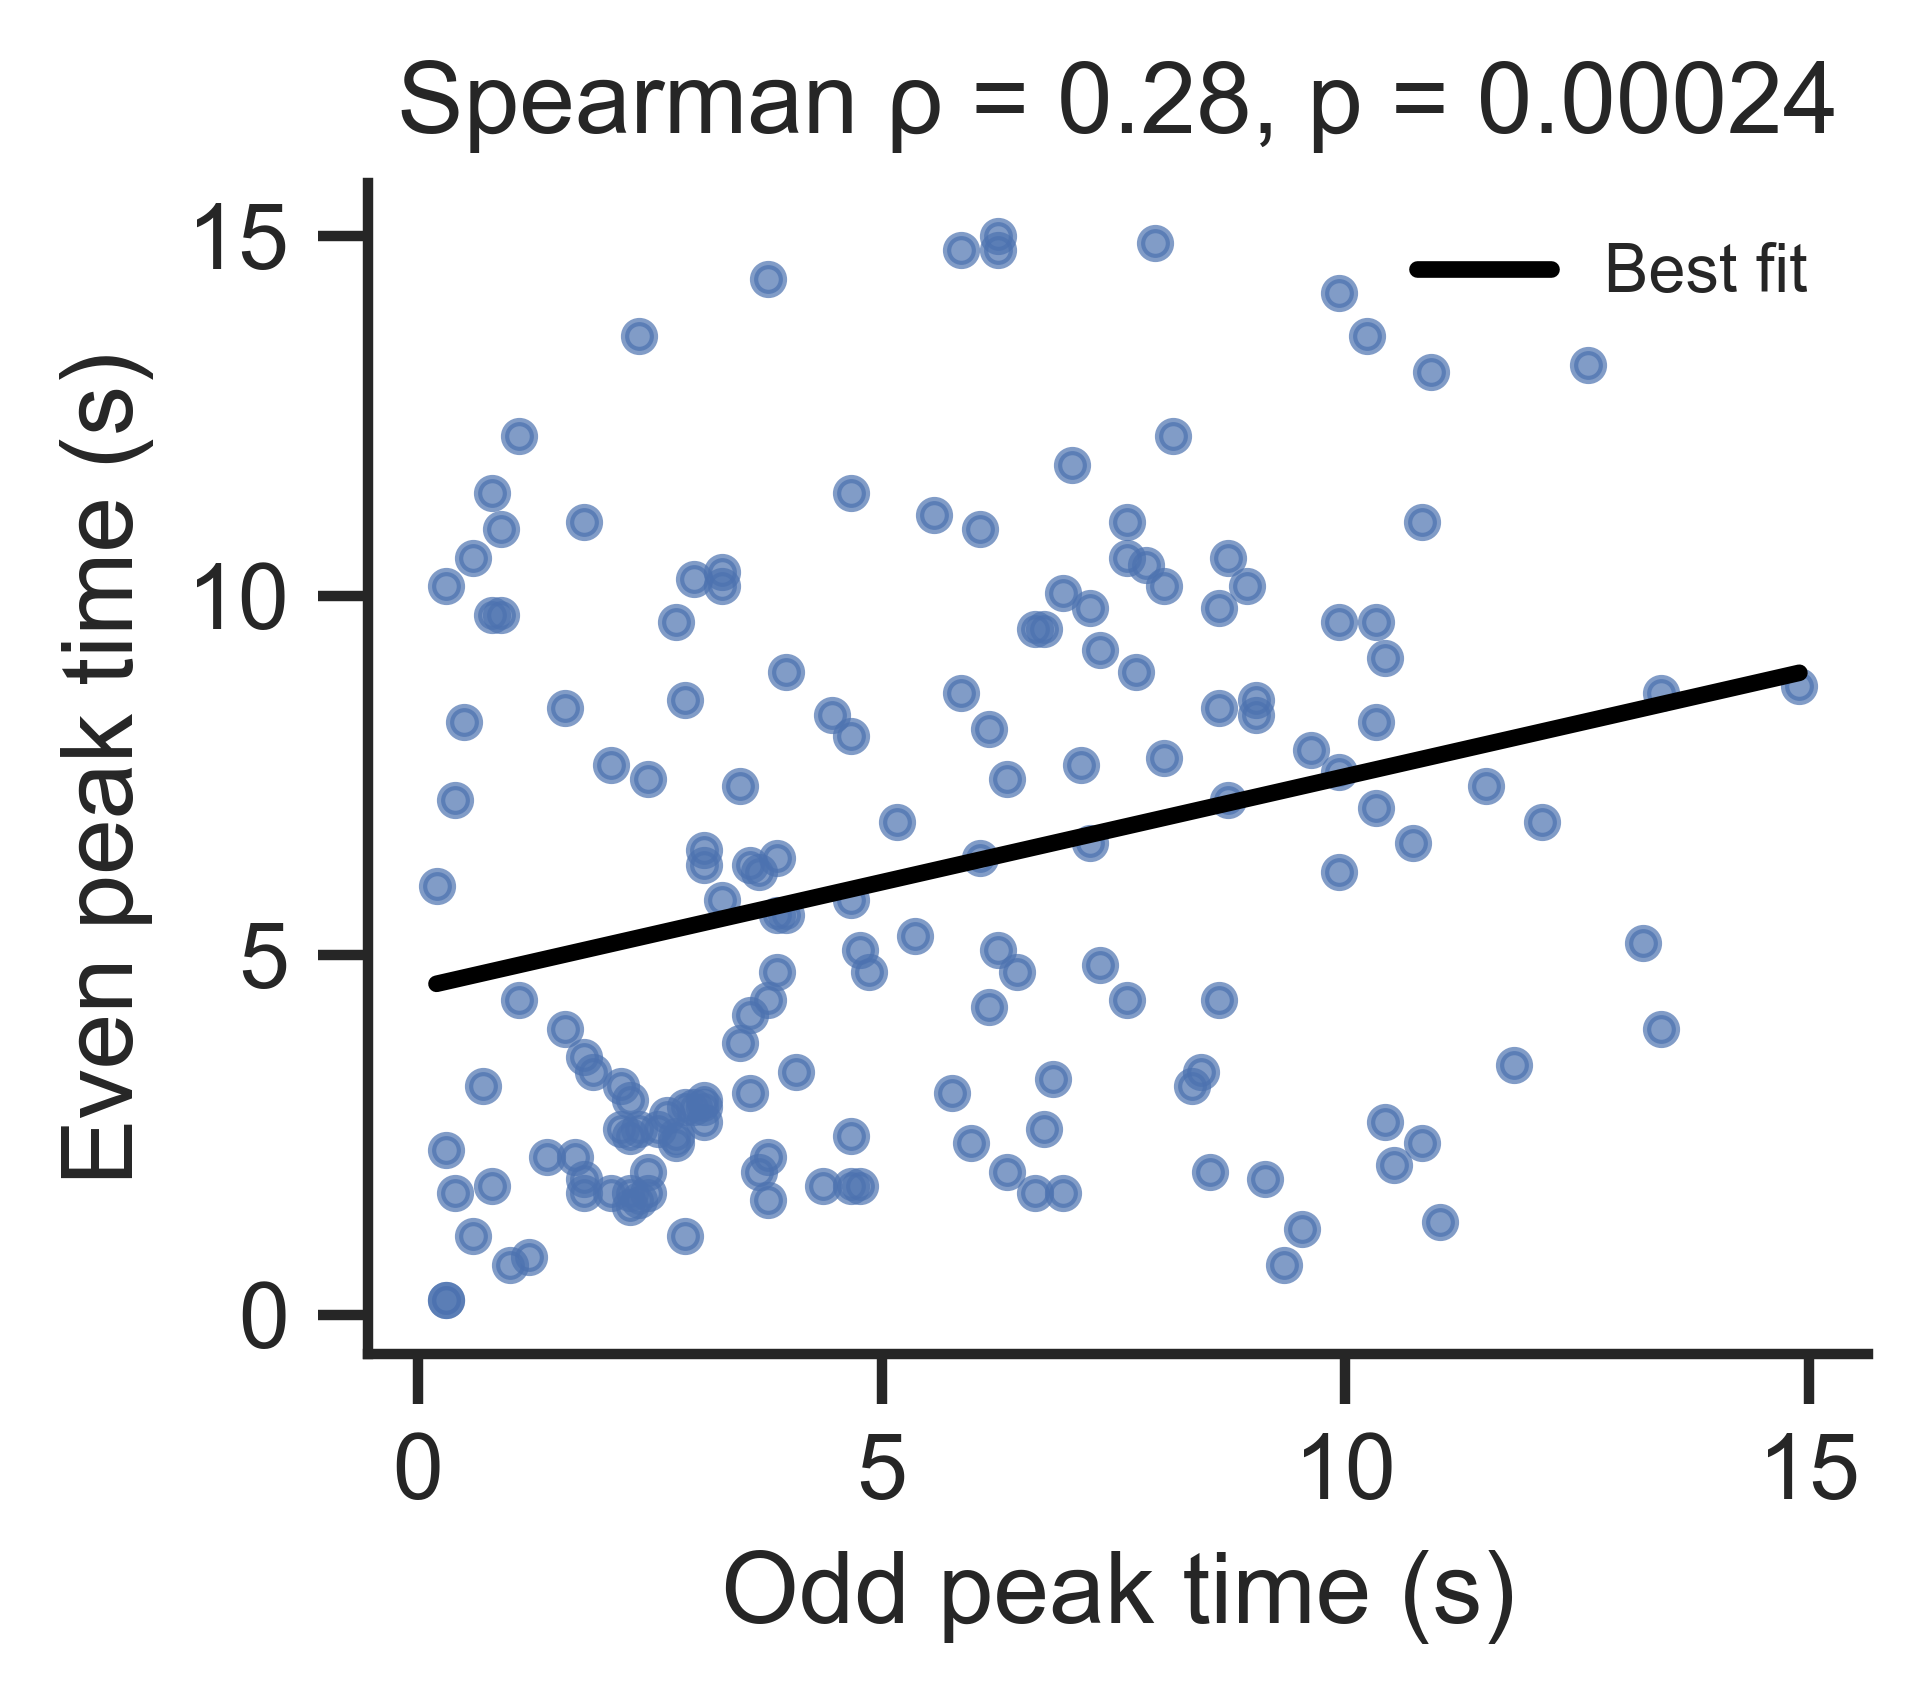

In [661]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

slope, intercept, r_val, p_val_lin, std_err = stats.linregress(odd_peaks_time, even_peaks_time)
x_line = np.linspace(min(odd_peaks_time), max(odd_peaks_time), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(3.5, 3), dpi=600)
plt.scatter(odd_peaks_time, even_peaks_time, s=12, alpha=0.7)
plt.plot(x_line, y_line, color='black', lw=2, label='Best fit')

plt.xlabel("Odd peak time (s)")
plt.ylabel("Even peak time (s)")
plt.title(f"Spearman ρ = {rho:.2f}, p = {pval:.2g}")
sns.despine()
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()

plt.savefig("/Users/suthardr/Desktop/siria_2p_poster_figs/crossvalled/neurons_shock_crossvalled_corr.svg")

plt.show()